# Ecommerce Full-Stack Analytics

## Python Exploratory Data Analysis

**Dataset:** Brazilian E-Commerce Public Dataset by Olist

**Technologies:** Python • Pandas • NumPy • Matplotlib • Seaborn • PostgreSQL • SQL • Power BI

### Objective

This notebook performs exploratory and business-oriented analysis of the Olist Brazilian e-commerce dataset.

The analysis focuses on:

- Data quality
- Revenue and order performance
- Customer behavior
- Product and category performance
- Delivery performance
- Customer reviews
- Business insights

The notebook complements the SQL analysis and Power BI dashboard developed as part of this project.

In [1]:
# Importing libararies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from getpass import getpass
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

DB_USER = input("PostgreSQL username: ")
DB_PASSWORD = getpass("PostgreSQL password: ")

DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "olist_db"

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)

engine = create_engine(connection_url)

try:
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
        print("PostgreSQL connection successful.")
except Exception as e:
    print("Connection failed.")
    print(e)

PostgreSQL connection successful.


In [3]:
# Loading Tables

customers = pd.read_sql(
    "SELECT * FROM customers",
    engine
)

orders = pd.read_sql(
    "SELECT * FROM orders",
    engine
)

products = pd.read_sql(
    "SELECT * FROM products",
    engine
)

order_items = pd.read_sql(
    "SELECT * FROM order_items",
    engine
)

payments = pd.read_sql(
    "SELECT * FROM payments",
    engine
)

reviews = pd.read_sql(
    "SELECT * FROM reviews",
    engine
)

print("Data loaded successfully.")

Data loaded successfully.


In [4]:
# Checking the datasets

tables = {
    "Customers": customers,
    "Orders": orders,
    "Products": products,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews
}

for name, df in tables.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Customers: 99,441 rows × 5 columns
Orders: 99,441 rows × 8 columns
Products: 32,951 rows × 9 columns
Order Items: 112,650 rows × 7 columns
Payments: 103,886 rows × 5 columns
Reviews: 99,224 rows × 7 columns


In [5]:
# Inspecting the orders table

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [6]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [7]:
orders.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,99441,NaN,NaN,NaN,2017-12-31 08:43:12.776581,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18
order_approved_at,99281,NaN,NaN,NaN,2017-12-31 18:35:24.098800,2016-09-15 12:16:38,2017-09-12 23:24:16,2018-01-19 11:36:13,2018-05-04 20:35:10,2018-09-03 17:40:06
order_delivered_carrier_date,97658,NaN,NaN,NaN,2018-01-04 21:49:48.138278,2016-10-08 10:34:01,2017-09-15 22:28:50.250000,2018-01-24 16:10:58,2018-05-08 13:37:45,2018-09-11 19:48:28
order_delivered_customer_date,96476,NaN,NaN,NaN,2018-01-14 12:09:19.035542,2016-10-11 13:46:32,2017-09-25 22:07:22.250000,2018-02-02 19:28:10.500000,2018-05-15 22:48:52.250000,2018-10-17 13:22:46
order_estimated_delivery_date,99441,NaN,NaN,NaN,2018-01-24 03:08:37.730111,2016-09-30 00:00:00,2017-10-03 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00


In [8]:
# Converting date columns

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [9]:
# Missing-value analysis

missing_values = (
    orders.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    orders.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": missing_percentage.round(2)
})

missing_summary

,missing_count,missing_percentage
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16
order_id,0,0.00
order_purchase_timestamp,0,0.00
order_status,0,0.00
customer_id,0,0.00
order_estimated_delivery_date,0,0.00


In [10]:
# Order status analysis

order_status = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = [
    "order_status",
    "total_orders"
]

order_status

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


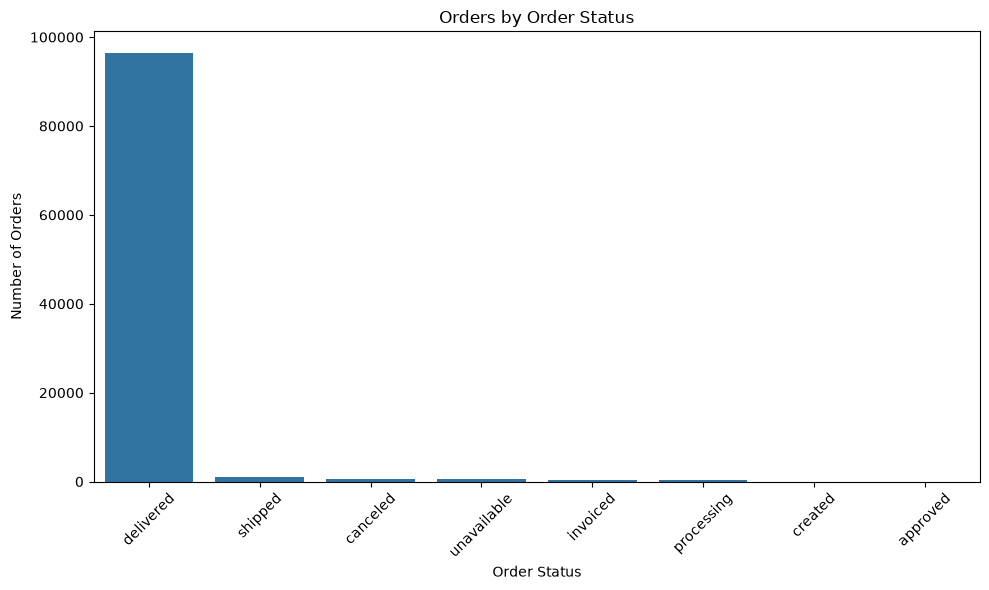

In [11]:
# Visualization

plt.figure(figsize=(10, 6))

sns.barplot(
    data=order_status,
    x="order_status",
    y="total_orders"
)

plt.title("Orders by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Revenue anaylsis

order_items["price"] = pd.to_numeric(
    order_items["price"],
    errors="coerce"
)

order_items["freight_value"] = pd.to_numeric(
    order_items["freight_value"],
    errors="coerce"
)

total_product_revenue = order_items["price"].sum()
total_freight = order_items["freight_value"].sum()

print(f"Total product revenue: R$ {total_product_revenue:,.2f}")
print(f"Total freight value: R$ {total_freight:,.2f}")

Total product revenue: R$ 13,591,643.70
Total freight value: R$ 2,251,909.54


In [13]:
# Monthly revenue

delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

order_revenue = delivered_orders[
    ["order_id", "order_purchase_timestamp"]
].merge(
    order_items[
        ["order_id", "price"]
    ],
    on="order_id",
    how="inner"
)

order_revenue["purchase_month"] = (
    order_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    order_revenue
    .groupby("purchase_month")["price"]
    .sum()
    .reset_index()
)

monthly_revenue.columns = [
    "purchase_month",
    "revenue"
]

monthly_revenue.head()

,purchase_month,revenue
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40


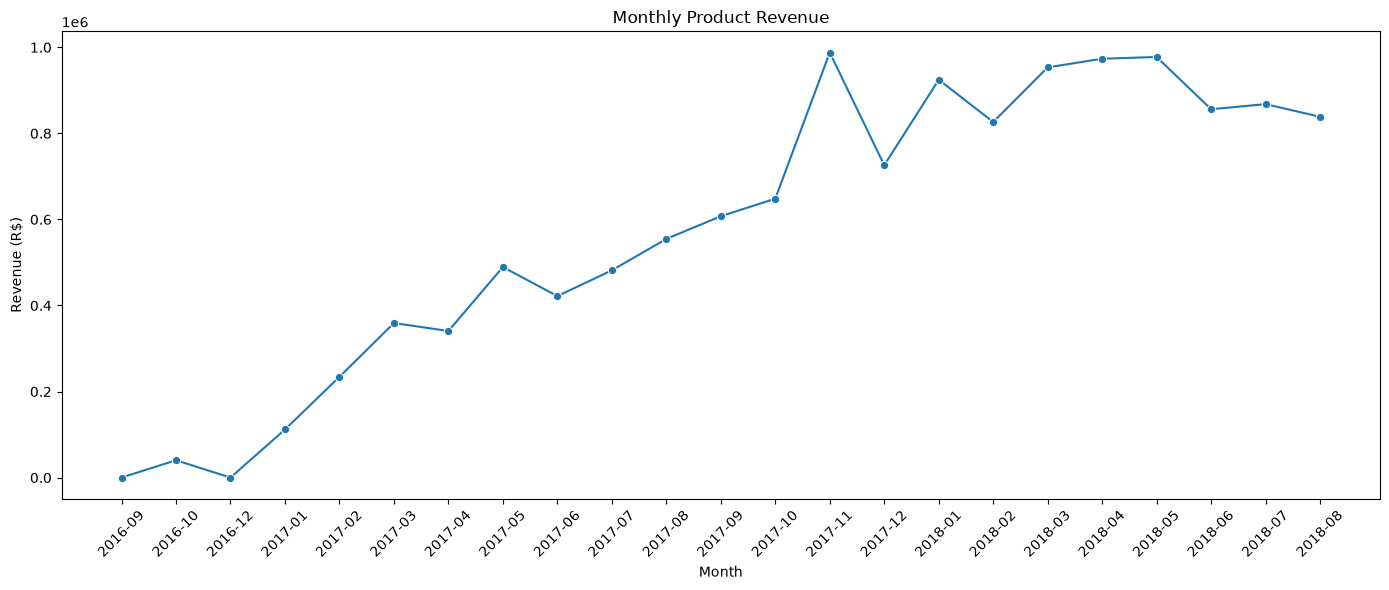

In [14]:
# Plot monthly revenue

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_revenue,
    x="purchase_month",
    y="revenue",
    marker="o"
)

plt.title("Monthly Product Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Customer analysis
customer_orders = (
    delivered_orders
    .groupby("customer_id")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

customer_orders.head()

,customer_id,total_orders
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


In [16]:
# Customer Revenue

customer_revenue = (
    order_revenue
    .groupby("order_id")["price"]
    .sum()
    .reset_index(name="order_revenue")
)

customer_revenue = (
    customer_revenue
    .merge(
        delivered_orders[
            ["order_id", "customer_id"]
        ],
        on="order_id",
        how="left"
    )
)

customer_revenue_summary = (
    customer_revenue
    .groupby("customer_id")["order_revenue"]
    .sum()
    .reset_index()
)

customer_revenue_summary = customer_revenue_summary.sort_values(
    "order_revenue",
    ascending=False
)

customer_revenue_summary.head(10)

,customer_id,order_revenue
8293,1617b1357756262bfa56ab541c47bc16,13440.0
89276,ec5b2ba62e574342386871631fafd3fc,7160.0
75240,c6e2731c5b391845f6800c97401a43a9,6735.0
92311,f48d464a0baaea338cb25f816991ab1f,6729.0
24068,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0
2007,05455dfa7cd02f13d132aa7a6a9729c6,5934.6
84350,df55c14d1476a9a3467f131269c2477f,4799.0
13870,24bbf5fd2f2e1b359ee7de94defc4a15,4690.0
23252,3d979689f636322c62418b6346b1c6d2,4590.0
77364,cc803a2c412833101651d3f90ca7de24,4400.0


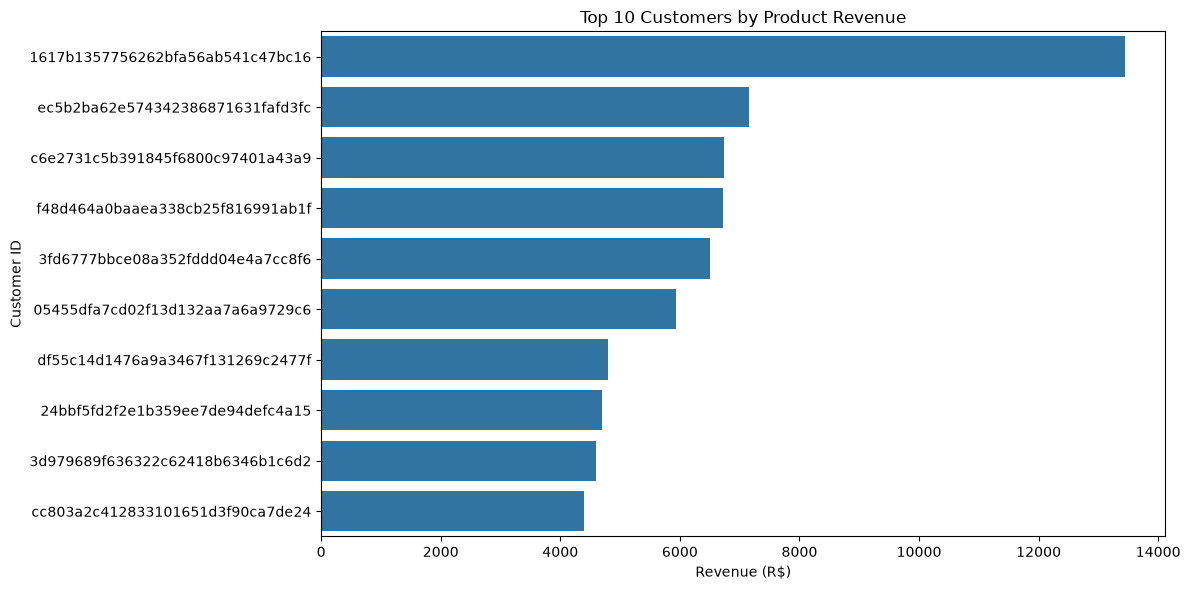

In [17]:
# Top customers

top_customers = customer_revenue_summary.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_customers,
    x="order_revenue",
    y="customer_id"
)

plt.title("Top 10 Customers by Product Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

In [18]:
# Product category analysis

product_category = products[
    ["product_id", "product_category_name"]
]

category_revenue = (
    order_items[
        ["order_id", "product_id", "price"]
    ]
    .merge(
        product_category,
        on="product_id",
        how="left"
    )
)

category_revenue = category_revenue[
    category_revenue["order_id"].isin(
        delivered_orders["order_id"]
    )
]

category_summary = (
    category_revenue
    .groupby("product_category_name")
    .agg(
        revenue=("price", "sum"),
        units_sold=("product_id", "count")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

category_summary.head(15)

,product_category_name,revenue,units_sold
11,beleza_saude,1233131.72,9465
66,relogios_presentes,1166176.98,5859
13,cama_mesa_banho,1023434.76,10953
32,esporte_lazer,954852.55,8431
44,informatica_acessorios,888724.61,7644
54,moveis_decoracao,711927.69,8160
72,utilidades_domesticas,615628.69,6795
26,cool_stuff,610204.10,3718
8,automotivo,578966.65,4140
12,brinquedos,471286.48,4030


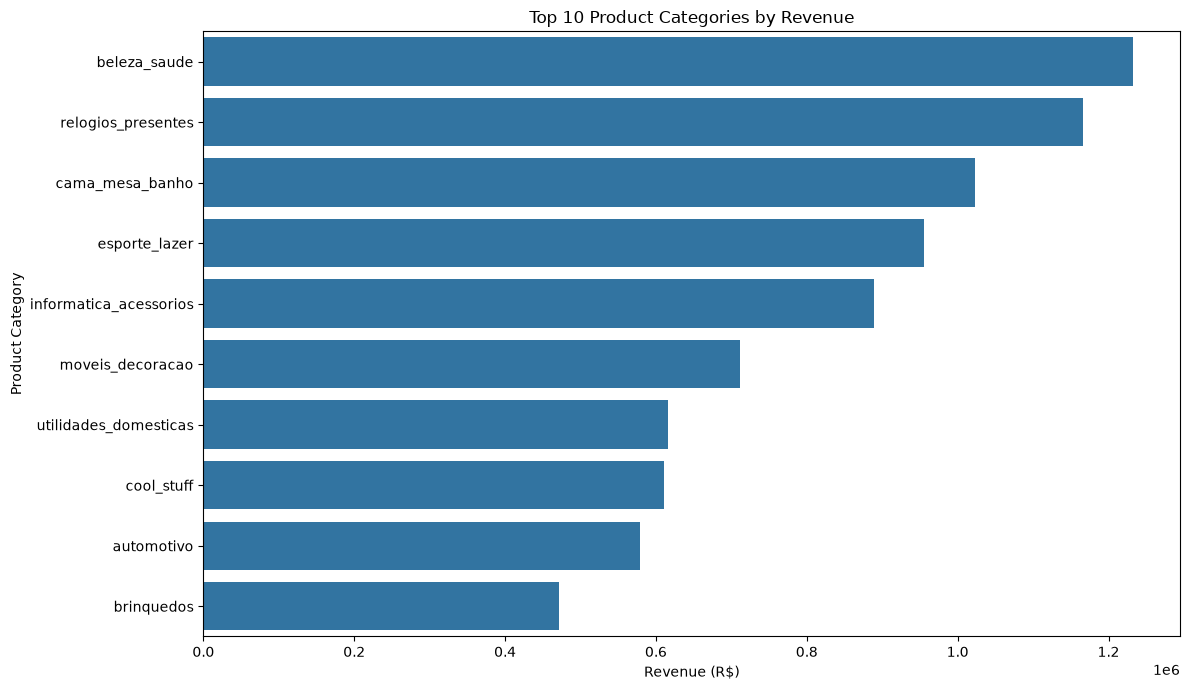

In [19]:
# Top product categories

top_categories = category_summary.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_categories,
    x="revenue",
    y="product_category_name"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [20]:
# Delivery analysis

delivery_data = delivered_orders[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

delivery_data["delivery_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivery_data["late_delivery"] = (
    delivery_data["order_delivered_customer_date"]
    >
    delivery_data["order_estimated_delivery_date"]
)

delivery_data[
    ["delivery_days", "late_delivery"]
].describe(include="all")

,delivery_days,late_delivery
count,96470.000000,96478
unique,NaN,2
top,NaN,False
freq,NaN,88652
mean,12.558217,NaN
std,9.546156,NaN
min,0.533414,NaN
25%,6.766204,NaN
50%,10.217477,NaN
75%,15.720182,NaN


In [21]:
# Delivery KPIs

average_delivery_days = delivery_data[
    "delivery_days"
].mean()

late_delivery_rate = (
    delivery_data["late_delivery"]
    .mean() * 100
)

print(
    f"Average delivery time: "
    f"{average_delivery_days:.2f} days"
)

print(
    f"Late delivery rate: "
    f"{late_delivery_rate:.2f}%"
)

Average delivery time: 12.56 days
Late delivery rate: 8.11%


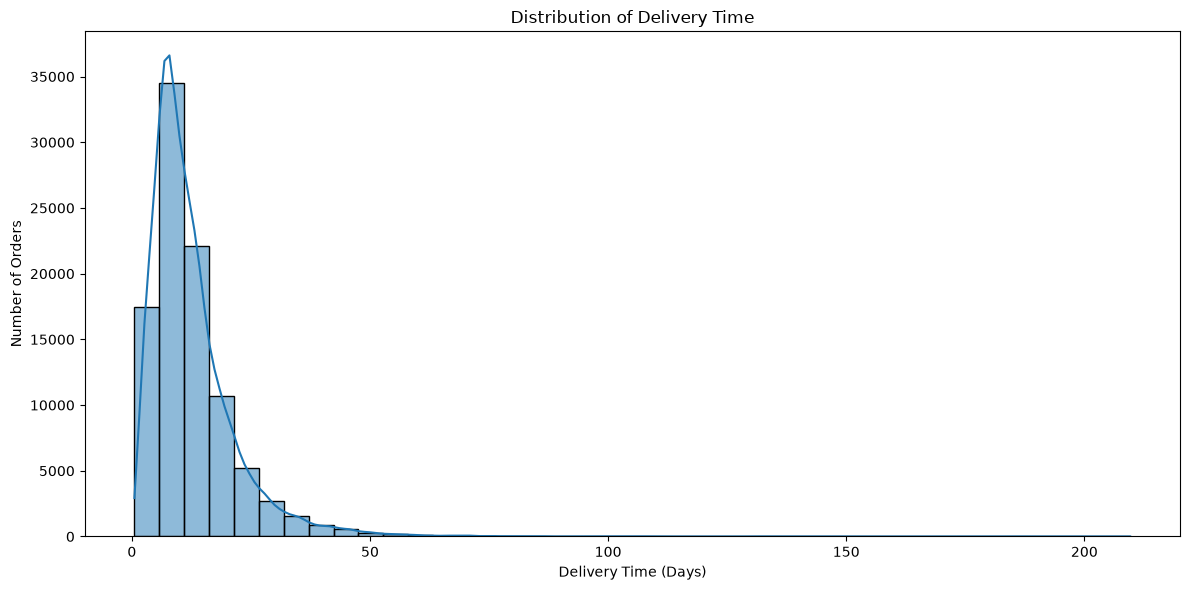

In [22]:
# Delivery distribution 

plt.figure(figsize=(12, 6))

sns.histplot(
    data=delivery_data,
    x="delivery_days",
    bins=40,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [23]:
# Review analysis

review_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_distribution.columns = [
    "review_score",
    "total_reviews"
]

review_distribution

,review_score,total_reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


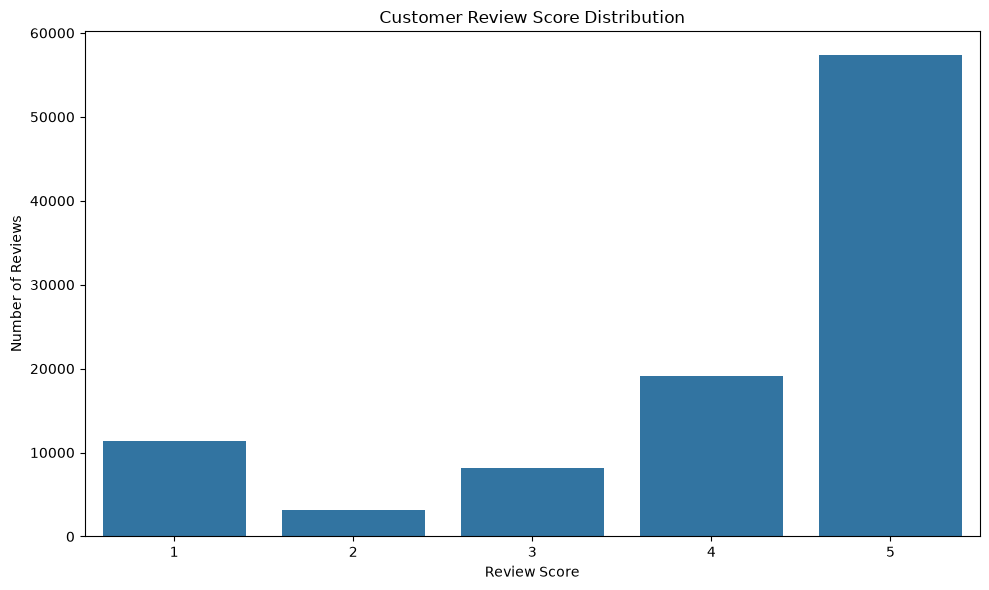

In [24]:
# Review visualization

plt.figure(figsize=(10, 6))

sns.barplot(
    data=review_distribution,
    x="review_score",
    y="total_reviews"
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [25]:
# Delivery vs review resource

delivery_review = (
    delivery_data[
        ["order_id", "late_delivery"]
    ]
    .merge(
        reviews[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

delivery_review_summary = (
    delivery_review
    .groupby("late_delivery")["review_score"]
    .mean()
    .reset_index()
)

delivery_review_summary


,late_delivery,review_score
0,False,4.293737
1,True,2.566494


In [26]:
delivery_review_summary["delivery_status"] = (
    delivery_review_summary["late_delivery"]
    .map({
        False: "On Time",
        True: "Late"
    })
)

delivery_review_summary

,late_delivery,review_score,delivery_status
0,False,4.293737,On Time
1,True,2.566494,Late


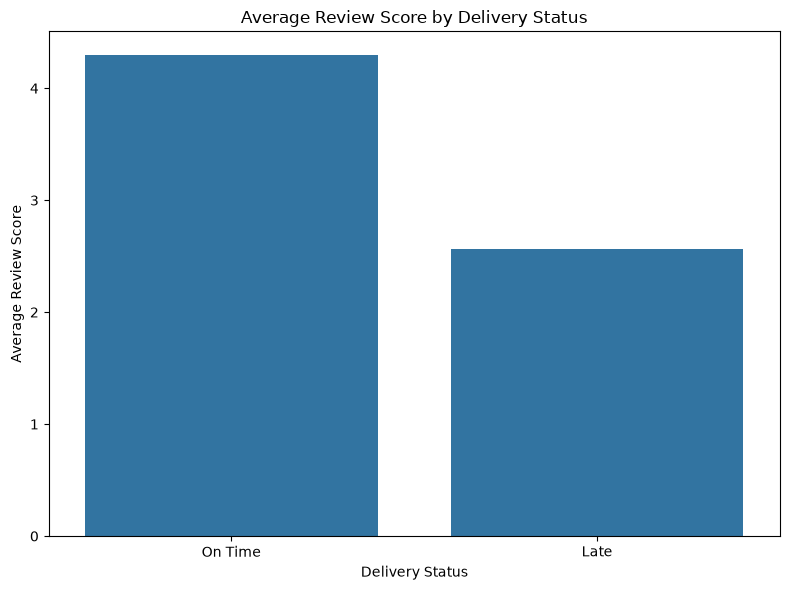

In [27]:
# Visualize it

plt.figure(figsize=(8, 6))

sns.barplot(
    data=delivery_review_summary,
    x="delivery_status",
    y="review_score"
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.show()

In [28]:
# Executive KPI summary

total_orders = delivered_orders["order_id"].nunique()

total_customers = delivered_orders["customer_id"].nunique()

total_revenue = order_revenue["price"].sum()

average_order_value = (
    total_revenue / total_orders
)

average_review_score = reviews["review_score"].mean()

print("========== EXECUTIVE KPI SUMMARY ==========")
print(f"Total delivered orders: {total_orders:,}")
print(f"Total customers: {total_customers:,}")
print(f"Product revenue: R$ {total_revenue:,.2f}")
print(f"Average order value: R$ {average_order_value:,.2f}")
print(f"Average review score: {average_review_score:.2f}")
print(f"Average delivery time: {average_delivery_days:.2f} days")
print(f"Late delivery rate: {late_delivery_rate:.2f}%")

========== EXECUTIVE KPI SUMMARY ==========
Total delivered orders: 96,478
Total customers: 96,478
Product revenue: R$ 13,221,498.11
Average order value: R$ 137.04
Average review score: 4.09
Average delivery time: 12.56 days
Late delivery rate: 8.11%


# Business Insights

## Revenue Performance

The analysis shows R$13.22 million in product revenue from 96,478 delivered orders, with an average order value of R$137.04.

Monthly revenue analysis shows a clear growth trajectory across the dataset period, with revenue increasing substantially during 2017 and 2018. This indicates strong expansion in marketplace transaction activity.

The analysis also shows that total product revenue across all order statuses is approximately R$13.59 million, while delivered orders account for R$13.22 million of product revenue.

### Business Implications
Monitor monthly revenue trends to identify periods of strong and weak demand.
Use revenue trends to support sales forecasting and inventory planning.
Investigate high-performing periods to identify products, categories, or customer segments driving growth.
Focus on increasing average order value through cross-selling, bundles, and product recommendations.

## Customers Performance

The analysis identified 96,478 customers associated with delivered orders. Customer-level revenue analysis also highlights a relatively small group of high-value customers contributing significantly to marketplace revenue.

The highest-revenue customer generated approximately R$13,440 in product purchases, followed by several other customers generating between approximately R$4,400 and R$7,160.

The customer analysis can therefore help identify valuable customers and support targeted retention strategies.

### Business Implications
Identify high-value customers for retention and loyalty initiatives.
Develop personalized promotions based on previous purchasing behavior.
Monitor customer purchase frequency and revenue contribution.
Use customer segmentation to distinguish high-value, occasional, and low-value customers.

## Product Category Performance

Product category analysis shows that health & beauty (beleza_saude) generated the highest delivered-order revenue at approximately R$1.23 million, followed by:

Watches & Gifts (relogios_presentes) — R$1.17 million
Bed, Bath & Table (cama_mesa_banho) — R$1.02 million
Sports & Leisure (esporte_lazer) — R$954.9 thousand
Computers & Accessories (informatica_acessorios) — R$888.7 thousand
Furniture & Decoration (moveis_decoracao) — R$711.9 thousand

The category analysis also shows differences between revenue and unit volume. For example, Bed, Bath & Table recorded approximately 10,953 units sold, while Health & Beauty generated higher revenue with approximately 9,465 units sold.

This suggests that revenue performance depends not only on sales volume but also on the average value of products sold.

### Business Implications
Prioritize high-revenue categories when planning inventory and marketing campaigns.
Compare revenue and units sold to identify categories with high volume but lower average selling prices.
Investigate opportunities to increase average order value within strong-performing categories.
Use category-level performance to guide product assortment and promotional decisions.

## Delivery Performance

Delivery performance is an important operational factor in the customer experience.

Among delivered orders, the average delivery time was 12.56 days. The analysis found that 8.11% of delivered orders were delivered after the estimated delivery date, while approximately 91.89% were delivered on time.

The delivery-time distribution also shows considerable variation, with some orders taking substantially longer than the average.

### Business Implications
Reduce late deliveries by identifying problematic carriers, regions, or operational stages.
Monitor delivery performance against estimated delivery dates.
Investigate unusually long delivery times and recurring delivery bottlenecks.
Improve estimated delivery dates where historical delivery performance suggests that current estimates are unrealistic.

## Customer Satisfaction

Customer reviews show a generally positive overall rating, with an average review score of 4.09 out of 5.

The distribution is strongly concentrated toward higher ratings:

5 stars: 57,328 reviews
4 stars: 19,142 reviews
3 stars: 8,179 reviews
2 stars: 3,151 reviews
1 star: 11,424 reviews

Although most reviews are positive, the 11,424 one-star reviews represent a significant group of dissatisfied customers and should be investigated.

### Business Implications
Analyze low-rated reviews to identify recurring customer complaints.
Link negative reviews to delivery performance, product categories, sellers, and other operational factors.
Use positive reviews to identify products and sellers that consistently meet customer expectations.
Develop corrective actions around the major causes of poor customer experiences.

## Delivery and Customer Satisfaction Relationship

The analysis reveals a strong relationship between delivery performance and customer satisfaction.

Customers whose orders were delivered on time gave an average review score of 4.29, while customers whose orders were delivered late gave an average score of only 2.57.

This represents a difference of approximately 1.73 rating points, demonstrating that delivery reliability is strongly associated with customer satisfaction.

### Business Implications
Delivery performance should be treated as a customer-experience KPI, not only an operational KPI.
Reducing late deliveries could have a meaningful impact on customer satisfaction.
Prioritize operational improvements that reduce delivery delays.
Monitor review scores alongside delivery KPIs to measure the customer impact of logistics improvements.

## Executive Business Summary

The analysis provides several important conclusions about the Olist marketplace:

96,478 delivered orders generated approximately R$13.22 million in product revenue.
The average delivered order generated approximately R$137.04 in product revenue.
Health & Beauty was the highest-revenue product category at approximately R$1.23 million.
Average delivery time was 12.56 days.
8.11% of delivered orders were late.
The overall average review score was 4.09/5.
On-time deliveries received an average score of 4.29, compared with only 2.57 for late deliveries.
The 1.73-point difference between on-time and late deliveries highlights the importance of logistics in customer satisfaction.

## Business Recommendations

Based on the analysis, the following actions could support business growth and operational improvement:

1. Improve Delivery Reliability

Focus on reducing the 8.11% late-delivery rate, particularly by identifying carriers, regions, sellers, or operational processes associated with delays.

2. Protect Customer Satisfaction

Because late deliveries are associated with substantially lower review scores, improving delivery performance should be a priority for customer-experience management.

3. Strengthen High-Performing Categories

Health & Beauty, Watches & Gifts, Bed, Bath & Table, and Sports & Leisure are among the strongest revenue-generating categories and should receive appropriate inventory and marketing attention.

4. Increase Customer Value

Use customer-level revenue analysis to identify high-value customers and develop targeted retention, loyalty, and cross-selling strategies.

5. Investigate Negative Reviews

The 11,424 one-star reviews provide an important source of information for identifying product, seller, delivery, and service problems.

6. Use Data for Operational Planning

Monthly revenue, category performance, delivery KPIs, and customer satisfaction metrics can be combined to support forecasting, inventory planning, logistics management, and strategic decision-making.

